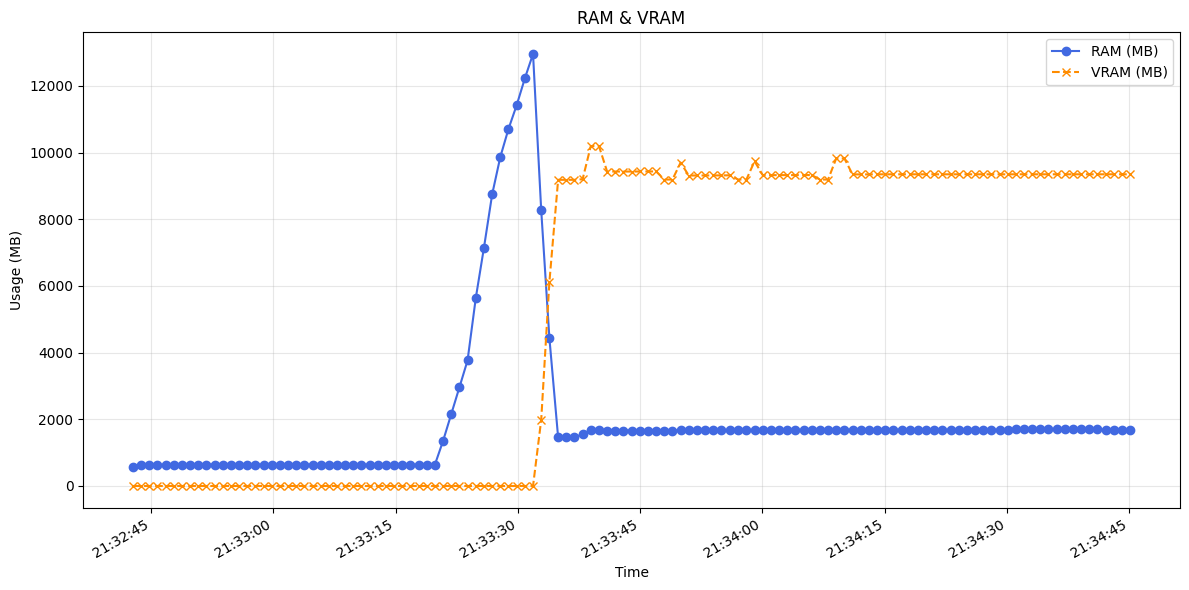

In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
from datetime import datetime


# 读取数据
df = pd.read_csv('resource_log_8.csv', sep=',')  # 根据实际分隔符调整，这里假设是制表符分隔

# 转换时间戳为datetime格式
df['timestamp'] = pd.to_datetime(df['timestamp'], unit='s')

# 创建画布
plt.figure(figsize=(12, 6))

# 绘制内存使用折线图
plt.plot(df['timestamp'], 
         df['memory_usage_mb'], 
         label='RAM (MB)', 
         marker='o',
         color='royalblue')

# 绘制GPU内存使用折线图
plt.plot(df['timestamp'], 
         df['gpu_memory_mb'], 
         label='VRAM (MB)', 
         marker='x',
         color='darkorange',
         linestyle='--')

# 设置格式
plt.title('RAM & VRAM')
plt.xlabel('Time')
plt.ylabel('Usage (MB)')
plt.grid(True, alpha=0.3)
plt.legend()

# 格式化时间轴
plt.gca().xaxis.set_major_formatter(mdates.DateFormatter('%H:%M:%S'))
plt.gcf().autofmt_xdate()  # 自动旋转日期标签

plt.tight_layout()
plt.show()

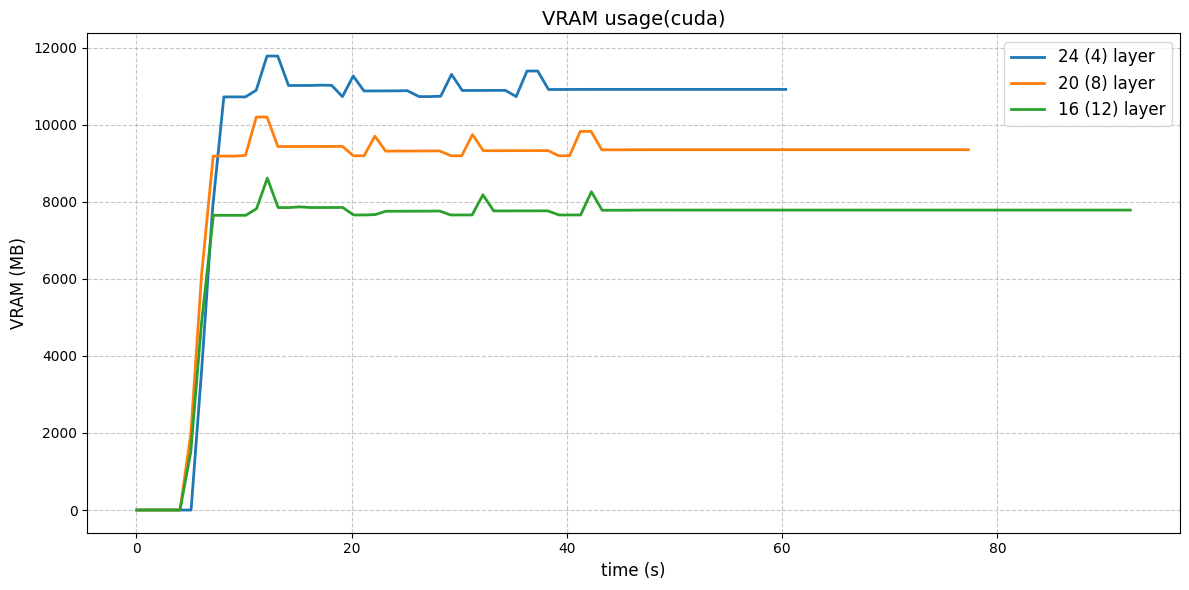

average 45-65s:
4layer: 10916.12 MB
8layer: 9349.76 MB
12layer: 7782.95 MB
16-20: 1566.82 MB
20-24: 1566.36 MB
16-24: 3133.17 MB


In [18]:
import os
layers = [4, 8, 12]

# 创建一个大的图形
plt.figure(figsize=(12, 6))
avg_values = {}

# 遍历每个层数
for layer in layers:
    # 构建文件名
    filename = f"resource_log_{layer}.csv"
    
    # 检查文件是否存在
    if not os.path.exists(filename):
        print(f"文件 {filename} 不存在，跳过")
        continue
    
    # 读取CSV文件
    df = pd.read_csv(filename)
    
    # 计算相对于第一个时间戳的时间差（秒）
    if layer == 4:
        df['relative_time'] = (df['timestamp'] - df['timestamp'].iloc[0] - 40) 
    if layer == 8:
        df['relative_time'] = (df['timestamp'] - df['timestamp'].iloc[0] - 45) 
    if layer == 12:
        df['relative_time'] = (df['timestamp'] - df['timestamp'].iloc[0] - 35) 
        
    df = df[df['relative_time'] >= 0]
        
    mask = (df['relative_time'] >= 45) & (df['relative_time'] <= 65)
    df_interval = df[mask]
    
    # 计算该区间的平均值
    avg = df_interval['gpu_memory_mb'].mean()
    avg_values[layer] = avg
    
    # 绘制内存使用折线图
    plt.plot(df['relative_time'], df['gpu_memory_mb'], 
             label=f'{28-layer} ({layer}) layer', 
             linewidth=2)

# 添加图表元素
plt.title('VRAM usage(cuda)', fontsize=14)
plt.xlabel('time (s)', fontsize=12)
plt.ylabel('VRAM (MB)', fontsize=12)
plt.grid(True, linestyle='--', alpha=0.7)
plt.legend(fontsize=12)
plt.tight_layout()

# 显示图形
plt.show()

print("average 45-65s:")
for layer, avg in avg_values.items():
    print(f"{layer}layer: {avg:.2f} MB")

print(f"16-20: {(avg_values[8]-avg_values[12]):.2f} MB")
print(f"20-24: {(avg_values[4]-avg_values[8]):.2f} MB")
print(f"16-24: {(avg_values[4]-avg_values[12]):.2f} MB")